# 01 Analisis Exploratorio de Datos (EDA)

Esta libreta desarrolla la **Fase 2** del proyecto: limpieza de apoyo, analisis preliminar, visualizacion de tendencias y revision de correlaciones. La fase parte del dataset limpio generado en la fase 1 para evitar repetir transformaciones ETL.

## 1. Preparacion del entorno

Importamos librerias y funciones reutilizables del proyecto. Si el dataset limpio no existe, se ejecuta primero el ETL de la fase 1.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.config import CLEANED_DATA_PATH
from src.etl import run_etl
from src.eda import build_eda_tables, load_cleaned_data, run_eda

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## 2. Carga del dataset limpio

La fase EDA utiliza `data/cleaned/climate_change_cleaned.csv`, que ya contiene nombres de columnas normalizados, tipos consistentes y validaciones de calidad.

In [2]:
if not CLEANED_DATA_PATH.exists():
    run_etl()

df = load_cleaned_data(CLEANED_DATA_PATH)
display(df.head())
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

,year,country,avg_temperature_c,co2_emissions_tons_capita,sea_level_rise_mm,rainfall_mm,population,renewable_energy_pct,extreme_weather_events,forest_area_pct
0,2000,Argentina,16.900,3.900,4.000,2047,564877556,15.500,11,18.400
1,2001,Argentina,33.200,18.200,2.900,2372,1078565697,15.700,1,39.700
2,2001,Argentina,24.800,14.300,2.800,2813,332640493,33.800,12,15.600
3,2001,Argentina,21.500,1.100,4.700,2005,597841637,31.600,2,17.700
4,2001,Argentina,8.400,16.800,2.300,2035,1334032802,12.700,3,19.800


Filas: 1,000
Columnas: 10


## 3. Limpieza y analisis preliminar

Aunque la limpieza fuerte se hizo en la fase 1, en EDA se confirma que no existan valores faltantes, duplicados exactos o inconsistencias visibles antes de analizar patrones.

In [3]:
tables = build_eda_tables(df)

display(tables["preliminary_summary"])
display(df.dtypes.to_frame("tipo_dato"))
display(df.isna().sum().to_frame("valores_faltantes"))
print("Duplicados exactos:", int(df.duplicated().sum()))

,rows,columns,countries,year_min,year_max,missing_total,duplicate_exact_rows,numeric_columns,categorical_columns
0,1000,10,15,2000,2023,0,0,9,1


,tipo_dato
year,int64
country,str
avg_temperature_c,float64
co2_emissions_tons_capita,float64
sea_level_rise_mm,float64
rainfall_mm,int64
population,int64
renewable_energy_pct,float64
extreme_weather_events,int64
forest_area_pct,float64


,valores_faltantes
year,0
country,0
avg_temperature_c,0
co2_emissions_tons_capita,0
sea_level_rise_mm,0
rainfall_mm,0
population,0
renewable_energy_pct,0
extreme_weather_events,0
forest_area_pct,0


Duplicados exactos: 0


## 4. Estadisticas descriptivas

Se revisan medidas de tendencia central, dispersion y rango para entender la escala de cada variable numerica.

In [4]:
display(tables["numeric_summary"])

,variable,count,mean,std,min,25%,50%,75%,max,missing_values,unique_values
0,year,1000.000,2011.430,7.150,2000.000,2005.000,2012.000,2018.000,2023.000,0,24
1,avg_temperature_c,1000.000,19.880,8.540,5.000,12.180,20.100,27.220,34.900,0,292
2,co2_emissions_tons_capita,1000.000,10.430,5.610,0.500,5.570,10.700,15.400,20.000,0,194
3,sea_level_rise_mm,1000.000,3.010,1.150,1.000,2.000,3.000,4.000,5.000,0,41
4,rainfall_mm,1000.000,1738.760,708.980,501.000,1098.750,1726.000,2362.500,2999.000,0,799
5,population,1000.000,705383046.610,409390996.880,3660891.000,343624166.000,713116635.500,1073868037.250,1397016073.000,0,1000
6,renewable_energy_pct,1000.000,27.300,12.970,5.100,16.100,27.150,38.920,50.000,0,407
7,extreme_weather_events,1000.000,7.290,4.420,0.000,3.000,8.000,11.000,14.000,0,15
8,forest_area_pct,1000.000,40.570,17.400,10.100,25.600,41.150,55.800,70.000,0,473


## 5. Analisis por pais

El resumen por pais permite comparar promedios de temperatura, emisiones, precipitacion, energia renovable, eventos extremos y area forestal.

In [5]:
country_summary = tables["country_summary"]
display(country_summary)

display(country_summary.sort_values("avg_temperature_c", ascending=False).head(5))
display(country_summary.sort_values("avg_co2_emissions_tons_capita", ascending=False).head(5))

,country,records,avg_temperature_c,avg_co2_emissions_tons_capita,avg_sea_level_rise_mm,avg_rainfall_mm,avg_population,avg_renewable_energy_pct,avg_extreme_weather_events,avg_forest_area_pct
0,Argentina,67,19.300,10.450,3.170,1714.340,752426032.700,27.260,6.580,38.830
1,Australia,57,19.450,8.900,3.160,1720.960,721337194.560,25.620,6.670,40.850
2,Brazil,67,20.840,10.840,3.170,1795.010,668552942.570,28.790,6.880,39.770
3,Canada,67,20.010,10.110,3.140,1834.400,673278769.720,26.240,7.300,41.930
4,China,67,20.280,10.840,2.930,1834.180,607154076.790,29.130,7.390,44.300
5,France,66,19.380,10.970,3.190,1767.980,707568021.230,28.740,8.620,39.500
6,Germany,61,20.290,9.880,2.870,1741.480,756520900.410,28.710,6.840,42.600
7,India,70,19.760,10.690,2.900,1617.400,656623209.410,27.690,7.600,38.990
8,Indonesia,75,18.920,11.020,2.750,1808.160,716197355.930,26.530,7.530,40.520
9,Japan,63,20.450,10.960,3.080,1799.380,697009502.380,27.560,7.860,38.120


,country,records,avg_temperature_c,avg_co2_emissions_tons_capita,avg_sea_level_rise_mm,avg_rainfall_mm,avg_population,avg_renewable_energy_pct,avg_extreme_weather_events,avg_forest_area_pct
2,Brazil,67,20.840,10.840,3.170,1795.010,668552942.570,28.790,6.880,39.770
12,South Africa,73,20.740,9.620,2.890,1699.050,706981364.930,23.920,6.990,41.070
11,Russia,74,20.720,8.970,3.290,1690.000,708637014.150,28.510,7.490,38.510
10,Mexico,55,20.700,9.350,2.690,1807.890,738292021.130,27.520,6.440,43.380
9,Japan,63,20.450,10.960,3.080,1799.380,697009502.380,27.560,7.860,38.120


,country,records,avg_temperature_c,avg_co2_emissions_tons_capita,avg_sea_level_rise_mm,avg_rainfall_mm,avg_population,avg_renewable_energy_pct,avg_extreme_weather_events,avg_forest_area_pct
13,UK,65,18.490,12.650,2.960,1530.600,740116254.480,27.920,7.780,42.720
8,Indonesia,75,18.920,11.020,2.750,1808.160,716197355.930,26.530,7.530,40.520
5,France,66,19.380,10.970,3.190,1767.980,707568021.230,28.740,8.620,39.500
9,Japan,63,20.450,10.960,3.080,1799.380,697009502.380,27.560,7.860,38.120
14,USA,73,19.050,10.880,2.930,1734.550,740719845.810,25.720,7.160,38.530


## 6. Tendencias por anio

La agregacion anual ayuda a observar variaciones temporales en los indicadores climaticos principales.

In [6]:
yearly_summary = tables["yearly_summary"]
display(yearly_summary)

,year,records,avg_temperature_c,avg_co2_emissions_tons_capita,avg_sea_level_rise_mm,avg_rainfall_mm,avg_renewable_energy_pct,avg_extreme_weather_events,avg_forest_area_pct
0,2000,53,20.500,11.220,2.940,1687.740,27.570,7.830,41.890
1,2001,41,20.120,9.930,3.270,1756.900,25.660,7.680,42.220
2,2002,51,21.430,9.930,2.950,1928.750,25.860,7.060,41.060
3,2003,41,18.220,11.090,2.930,1826.710,26.590,7.980,39.170
4,2004,50,18.800,10.000,2.790,1713.920,29.470,6.420,42.240
5,2005,37,19.530,8.540,2.940,1594.950,24.710,7.700,40.740
6,2006,39,19.810,10.500,3.060,1946.970,29.360,7.670,40.700
7,2007,40,20.560,10.340,2.820,1662.400,24.370,7.600,42.190
8,2008,36,19.140,10.380,3.030,1724.330,28.300,8.000,43.020
9,2009,33,19.730,10.360,2.760,1581.420,25.880,6.090,44.290


## 7. Visualizaciones de distribuciones y tendencias

Se generan figuras en `reports/figures/` para documentar distribuciones, tendencias anuales, correlaciones y comparaciones por pais.

In [7]:
tables, figure_paths = run_eda()

outputs = pd.DataFrame(
    [{"figura": name, "ruta": str(path.relative_to(ROOT)), "existe": path.exists()} for name, path in figure_paths.items()]
)
outputs

,figura,ruta,existe
0,distributions,reports\figures\eda_distributions.png,True
1,yearly_trends,reports\figures\eda_yearly_trends.png,True
2,correlation_heatmap,reports\figures\eda_correlation_heatmap.png,True
3,country_temperature_co2,reports\figures\eda_country_temperature_co2.png,True


distributions C:\Users\ziuvar\Desktop\ANALISIS DATOS FINAL\reports\figures\eda_distributions.png


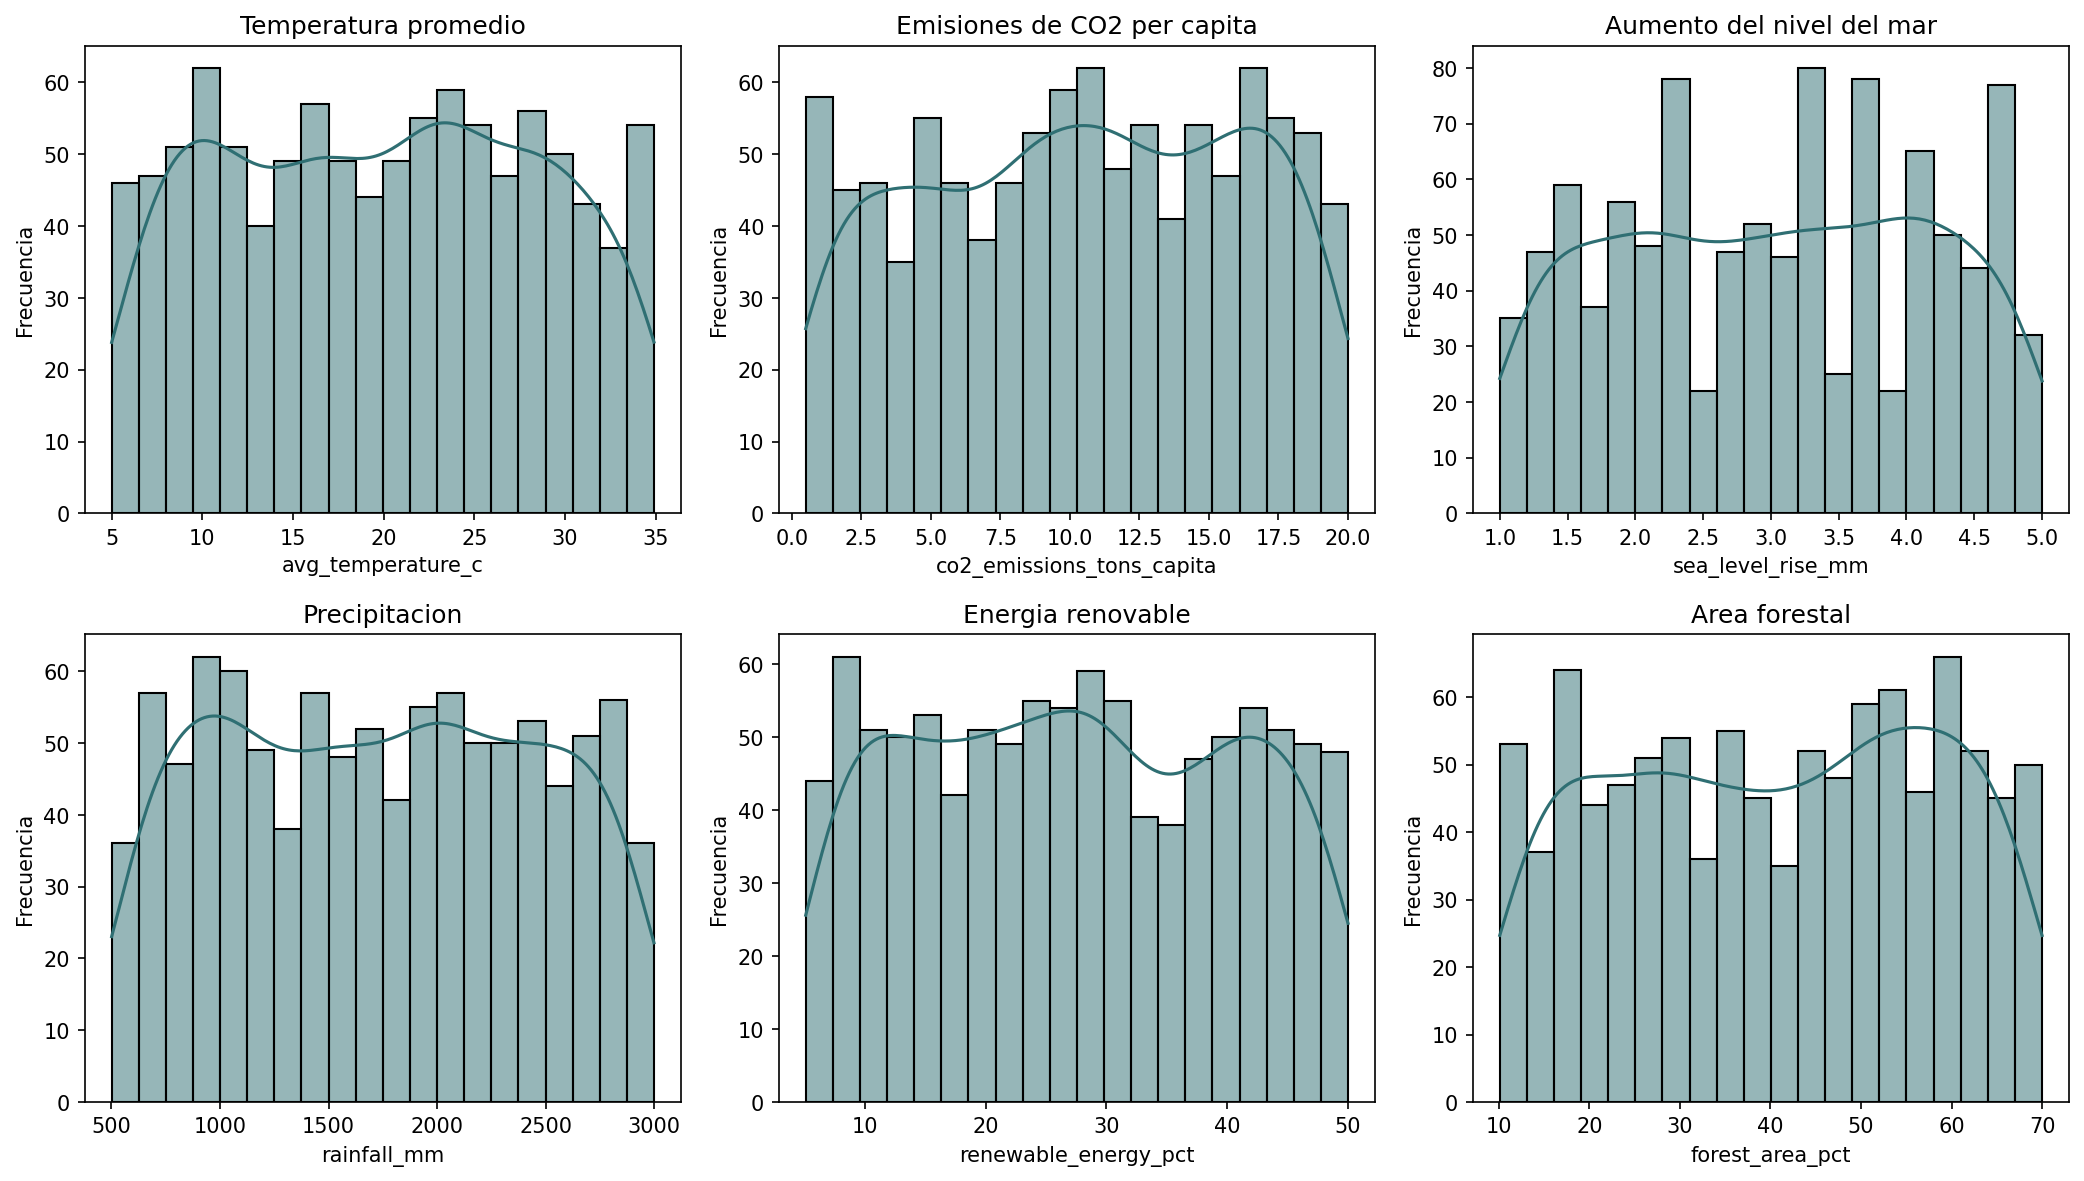

yearly_trends C:\Users\ziuvar\Desktop\ANALISIS DATOS FINAL\reports\figures\eda_yearly_trends.png


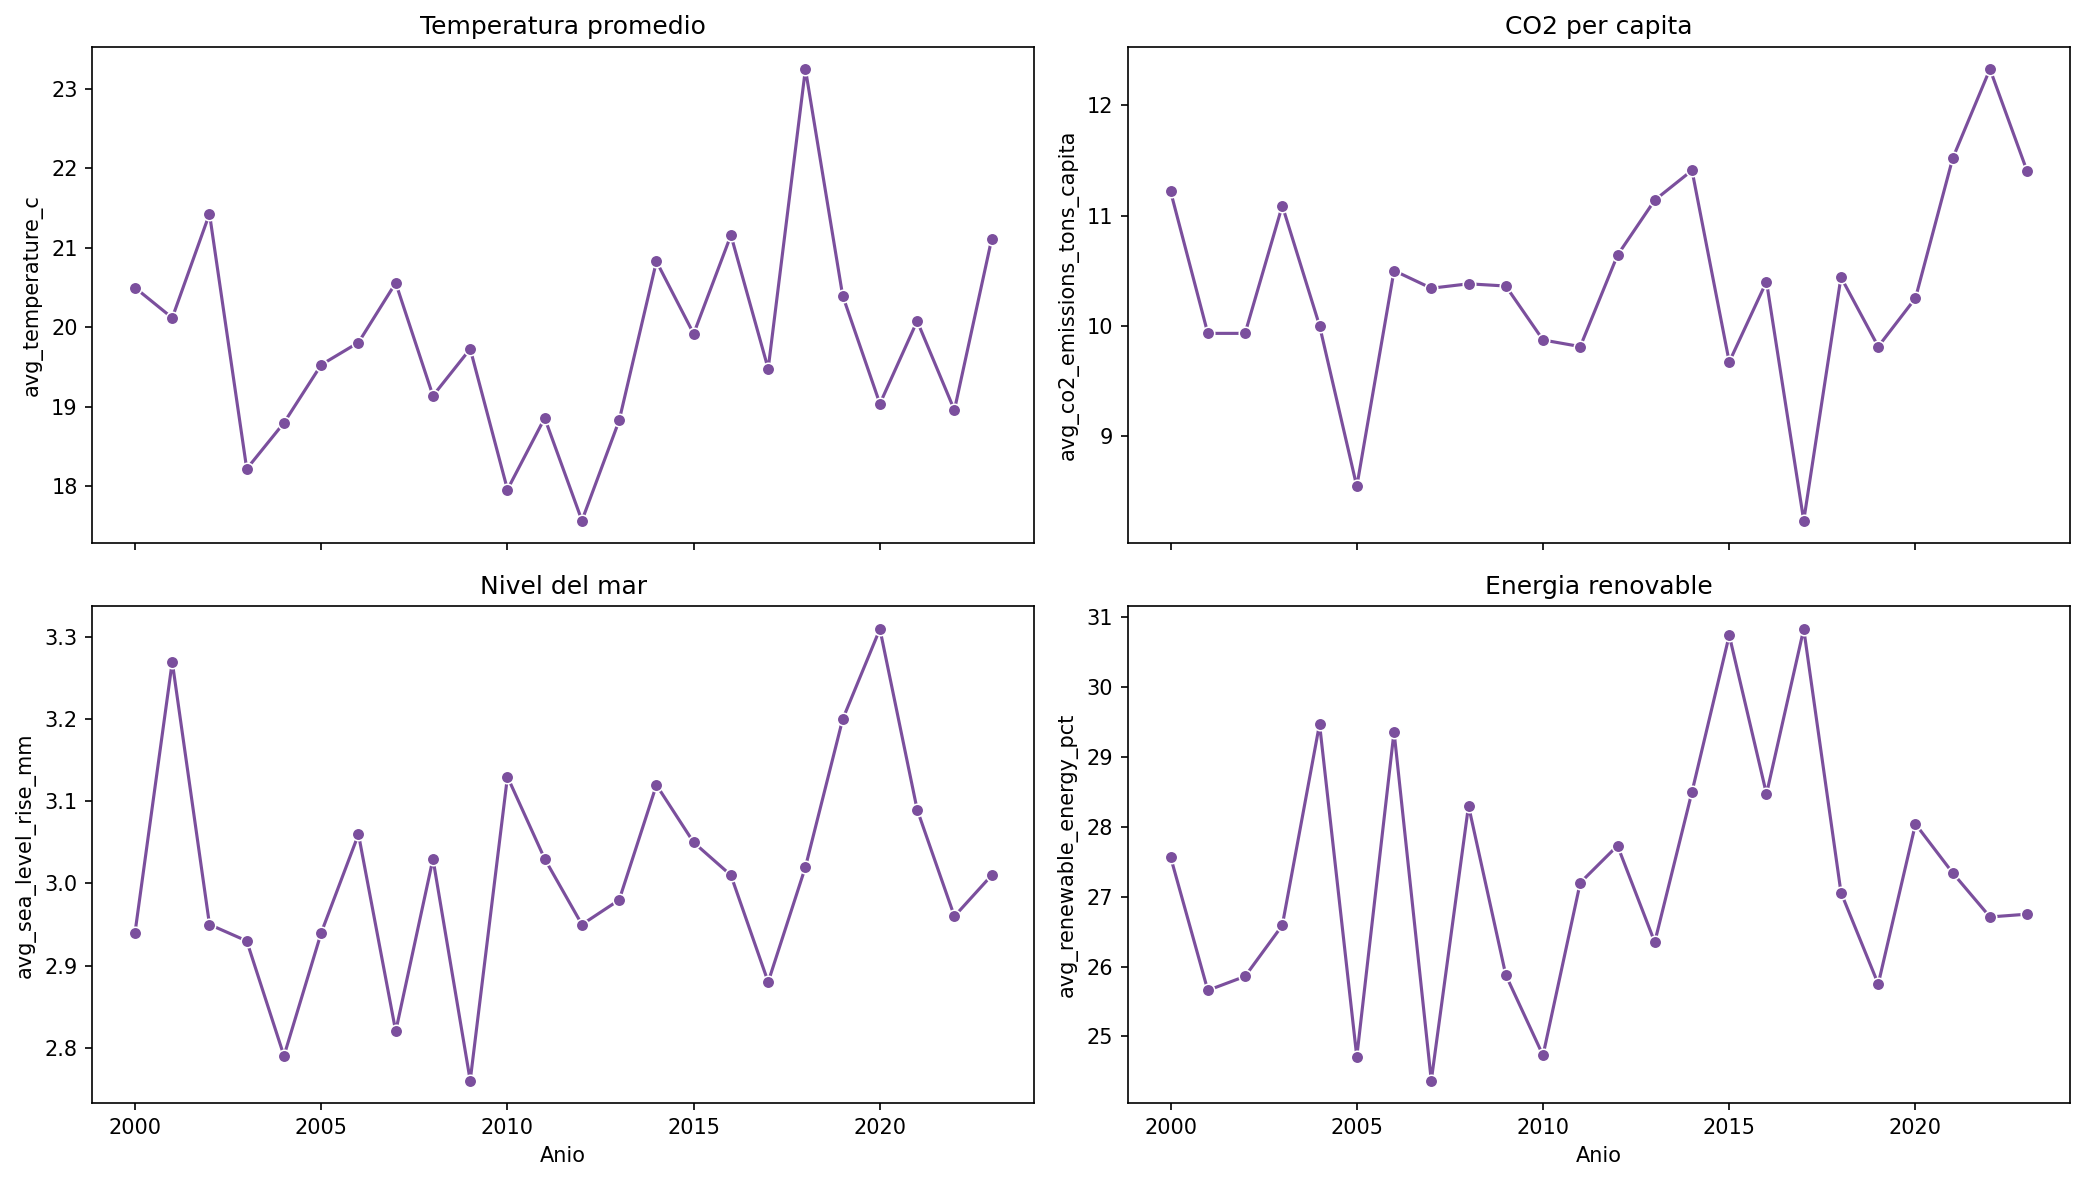

correlation_heatmap C:\Users\ziuvar\Desktop\ANALISIS DATOS FINAL\reports\figures\eda_correlation_heatmap.png


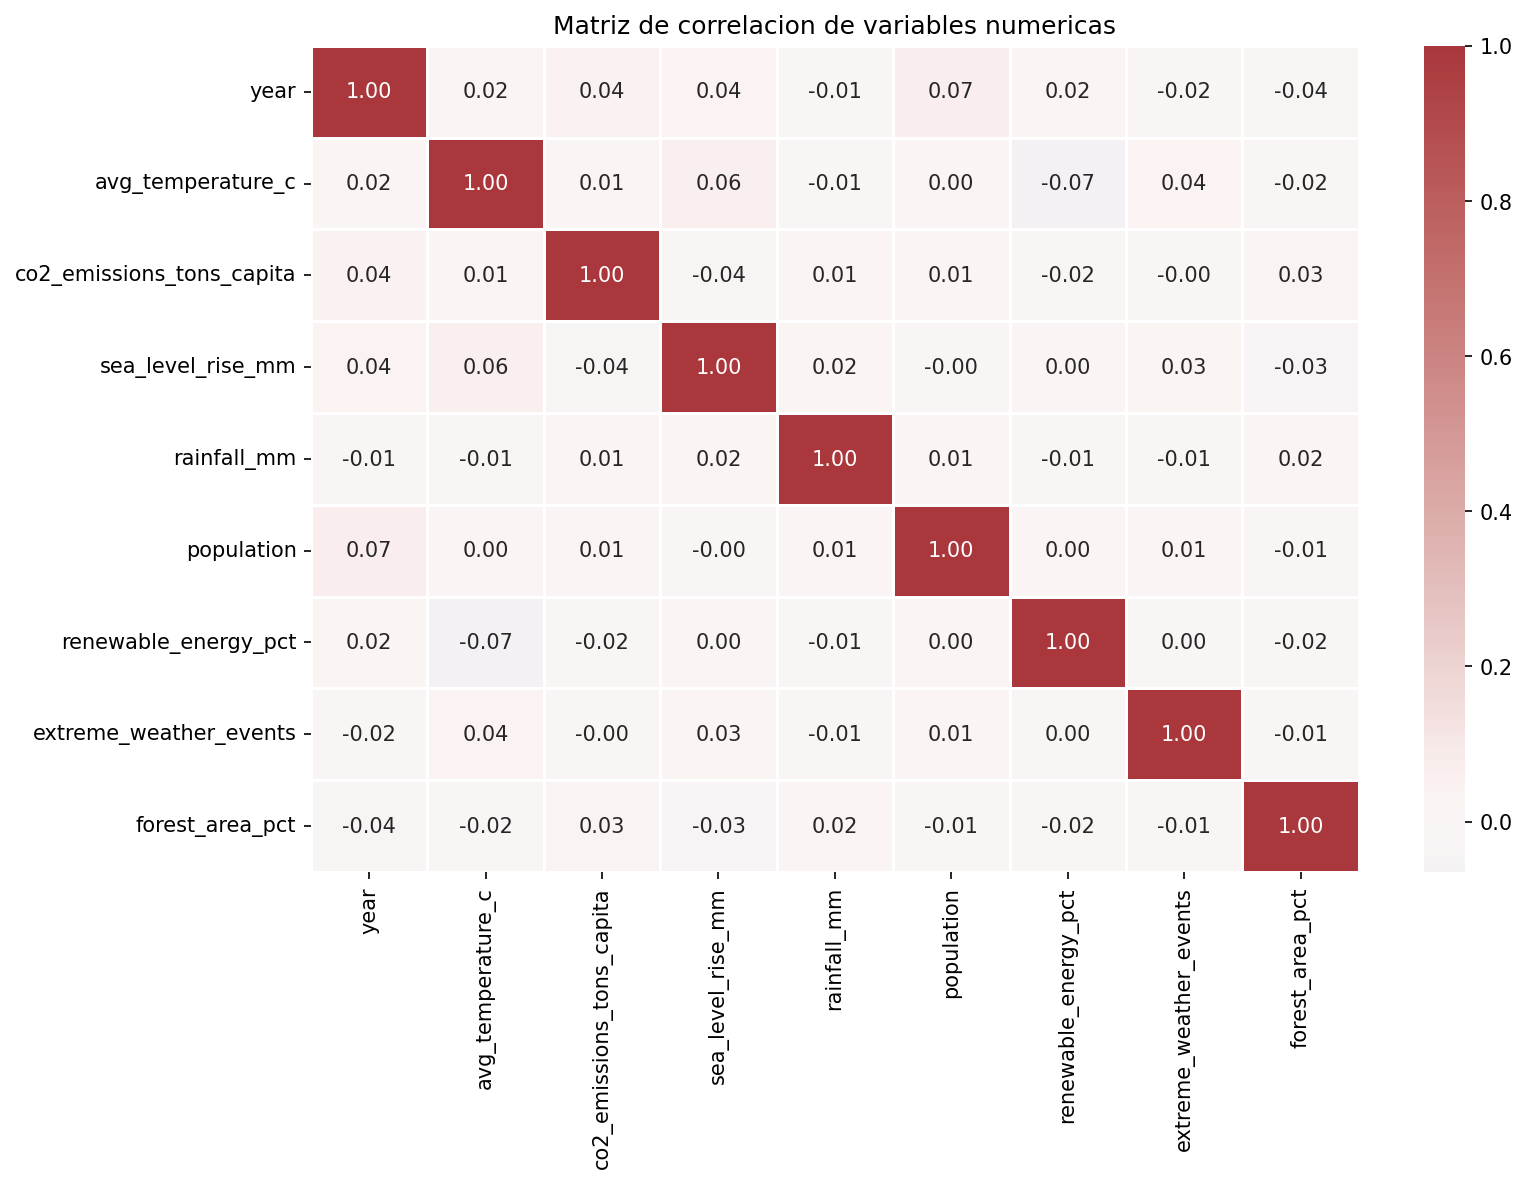

country_temperature_co2 C:\Users\ziuvar\Desktop\ANALISIS DATOS FINAL\reports\figures\eda_country_temperature_co2.png


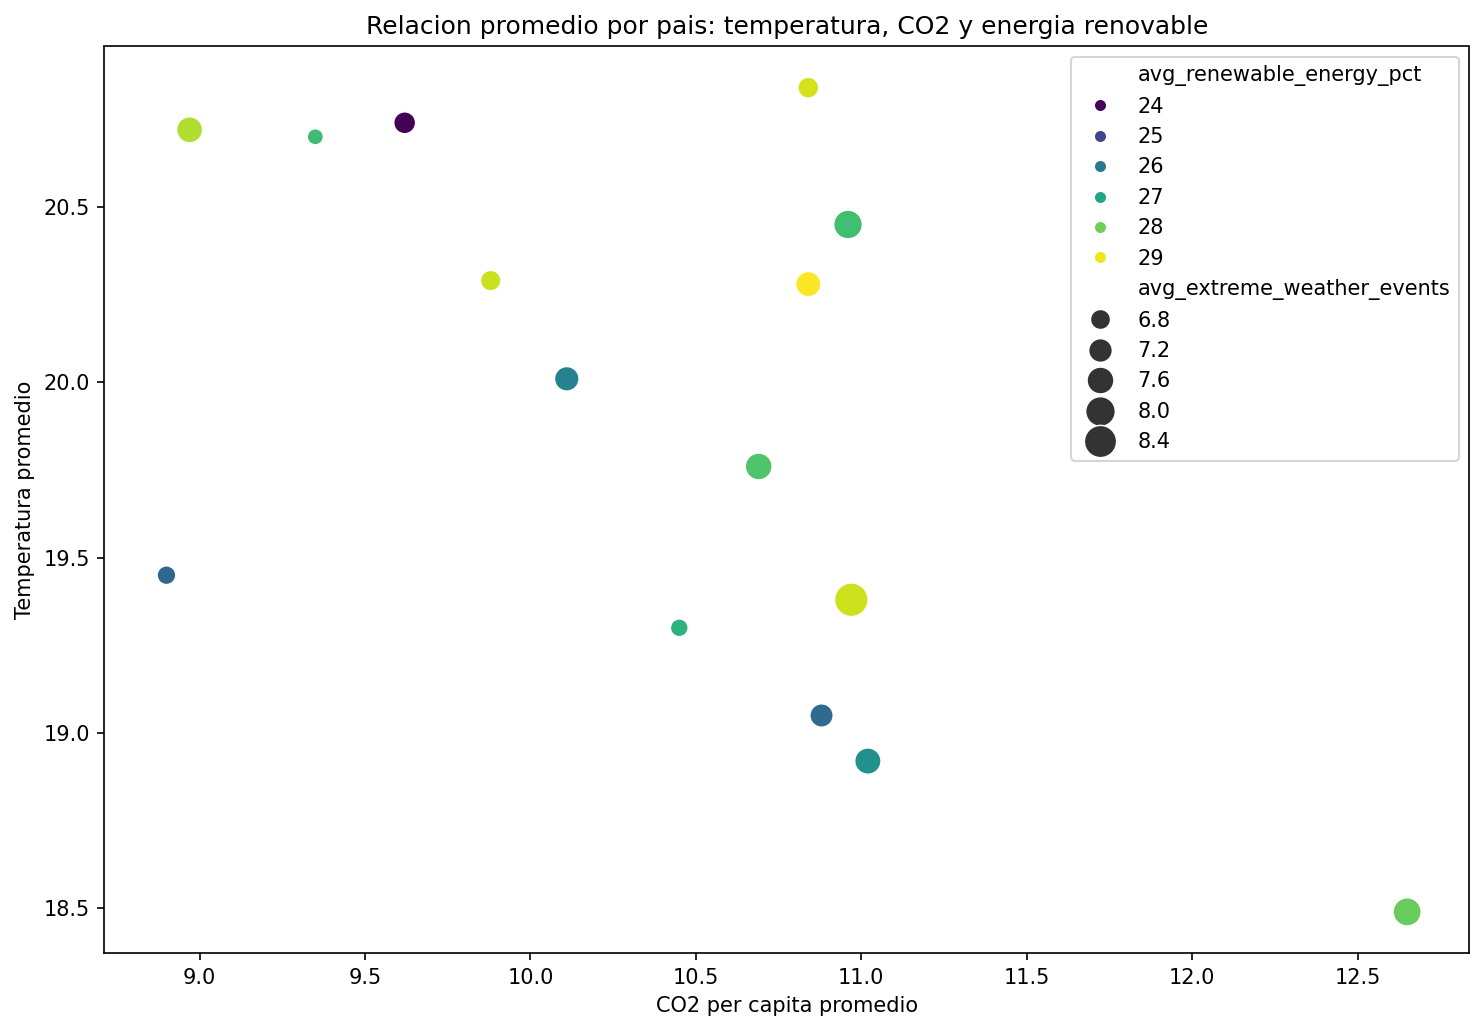

In [8]:
for name, path in figure_paths.items():
    print(name, path)
    display(Image(filename=str(path)))

## 8. Correlaciones

La matriz de correlacion permite identificar relaciones lineales entre variables numericas. Tambien se listan las correlaciones mas fuertes por valor absoluto.

In [9]:
display(tables["correlation_matrix"])
display(tables["top_correlations"].head(10))

,year,avg_temperature_c,co2_emissions_tons_capita,sea_level_rise_mm,rainfall_mm,population,renewable_energy_pct,extreme_weather_events,forest_area_pct
year,1.000,0.021,0.041,0.035,-0.014,0.072,0.024,-0.022,-0.041
avg_temperature_c,0.021,1.000,0.012,0.059,-0.005,0.004,-0.065,0.035,-0.017
co2_emissions_tons_capita,0.041,0.012,1.000,-0.039,0.013,0.012,-0.023,-0.004,0.031
sea_level_rise_mm,0.035,0.059,-0.039,1.000,0.022,-0.000,0.004,0.025,-0.029
rainfall_mm,-0.014,-0.005,0.013,0.022,1.000,0.009,-0.006,-0.007,0.019
population,0.072,0.004,0.012,-0.000,0.009,1.000,0.002,0.005,-0.012
renewable_energy_pct,0.024,-0.065,-0.023,0.004,-0.006,0.002,1.000,0.000,-0.021
extreme_weather_events,-0.022,0.035,-0.004,0.025,-0.007,0.005,0.000,1.000,-0.009
forest_area_pct,-0.041,-0.017,0.031,-0.029,0.019,-0.012,-0.021,-0.009,1.000


,variable_1,variable_2,correlation,absolute_correlation
0,year,population,0.072,0.072
1,avg_temperature_c,renewable_energy_pct,-0.065,0.065
2,avg_temperature_c,sea_level_rise_mm,0.059,0.059
3,year,co2_emissions_tons_capita,0.041,0.041
4,year,forest_area_pct,-0.041,0.041
5,co2_emissions_tons_capita,sea_level_rise_mm,-0.039,0.039
6,year,sea_level_rise_mm,0.035,0.035
7,avg_temperature_c,extreme_weather_events,0.035,0.035
8,co2_emissions_tons_capita,forest_area_pct,0.031,0.031
9,sea_level_rise_mm,forest_area_pct,-0.029,0.029


## 9. Hallazgos preliminares

- El dataset limpio conserva 1,000 registros, 15 paises y periodo 2000-2023.
- No se observan valores faltantes ni duplicados exactos en la base analizada.
- Las variables tienen escalas muy diferentes, especialmente poblacion, lluvia, emisiones y porcentajes; esto debera considerarse antes del modelado.
- Las correlaciones lineales mas altas observadas son bajas en esta muestra, por lo que conviene complementar el analisis con segmentaciones por pais, anio y posibles modelos supervisados.
- Las visualizaciones generadas sirven como insumo para el dashboard de BI y para seleccionar variables candidatas en la fase de aprendizaje computacional.

## 10. Entregables de la fase 2

Tablas generadas en `reports/tables/`:

- `eda_preliminary_summary.csv`
- `eda_numeric_summary.csv`
- `eda_country_summary.csv`
- `eda_yearly_summary.csv`
- `eda_correlation_matrix.csv`
- `eda_top_correlations.csv`

Figuras generadas en `reports/figures/`:

- `eda_distributions.png`
- `eda_yearly_trends.png`
- `eda_correlation_heatmap.png`
- `eda_country_temperature_co2.png`